# CIFAR_10

In [46]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split


In [73]:
# ----------------------------
# 1. Load CIFAR-10 from OpenML
# ----------------------------
X, y = fetch_openml(
    "CIFAR_10_small",
    version=1,
    return_X_y=True,
    as_frame=False,
    parser="auto"
)

X = X.astype(np.float32) / 255.0
y = y.astype(int)


# ----------------------------
# 2. Extract cat vs not-cat
# ----------------------------
cat_label = 3 # 3 is cat

cat_data = X[y == cat_label]
not_cat_data = X[y != cat_label]

# ----------------------------
# 3. Train/test split (manual)
# ----------------------------
np.random.seed(0)

cat_train, cat_test = train_test_split(cat_data, test_size=0.3, random_state=42)
print(cat_train.shape)
not_cat_train, not_cat_test = train_test_split(not_cat_data, test_size=0.3, random_state=42)


(1411, 3072)


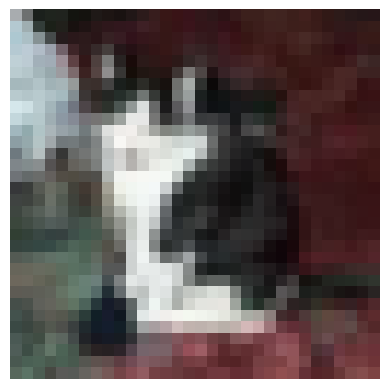

In [74]:
def plot_image(img):
    """
    Plot a single CIFAR image from flattened OpenML format (3072,).
    
    Parameters:
    - img: numpy array of shape (3072,)
    """
    # split channels (OpenML CIFAR format: R, G, B blocks)
    r = img[0:1024].reshape(32, 32)
    g = img[1024:2048].reshape(32, 32)
    b = img[2048:3072].reshape(32, 32)

    img_rgb = np.dstack([r, g, b])

    # plt.imshow(img_rgb.astype(np.uint8))
    plt.imshow(np.clip(img_rgb * 255, 0, 255).astype(np.uint8))
    plt.axis("off")
    plt.show()

plot_image(cat_data[44])

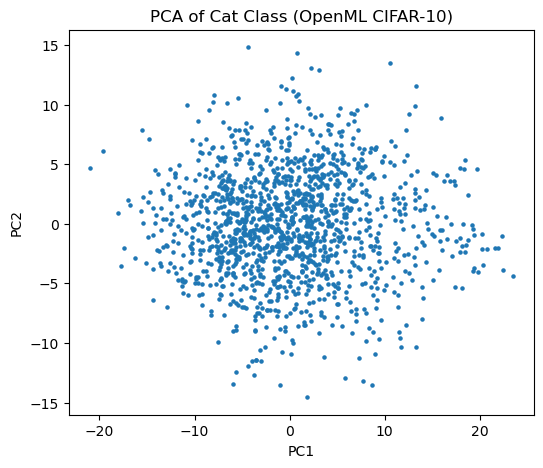

In [75]:
# ----------------------------
# 4. PCA (fit only on cats)
# ----------------------------
pca = PCA(n_components=100) # bcoz od rank of covariance matrix = # sample, n_components<=# sample=1411
cat_train_pca = pca.fit_transform(cat_train)

cat_test_pca = pca.transform(cat_test)
not_cat_test_pca = pca.transform(not_cat_test)

# ----------------------------
# 5. PCA visualization (2D)
# ----------------------------
pca_2d = PCA(n_components=2)
cat_train_2d = pca_2d.fit_transform(cat_train)

plt.figure(figsize=(6,5))
plt.scatter(cat_train_2d[:,0], cat_train_2d[:,1], s=5)
plt.title("PCA of Cat Class (OpenML CIFAR-10)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


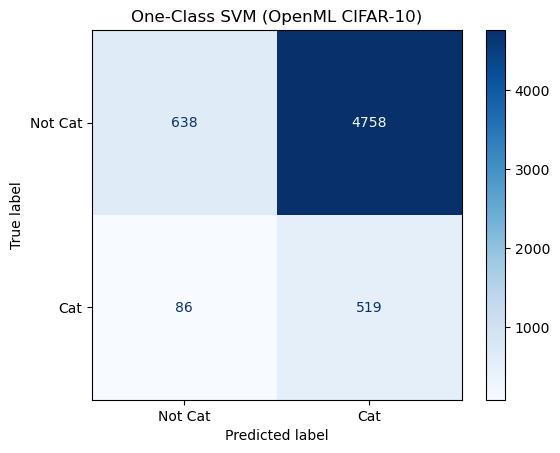

In [76]:
# ----------------------------
# 6. One-Class SVM
# ----------------------------
ocsvm = OneClassSVM(kernel="rbf", nu=0.1, gamma="scale")
ocsvm.fit(cat_train_pca)

# ----------------------------
# 7. Predictions
# ----------------------------
y_cat_pred = ocsvm.predict(cat_test_pca)          # +1 expected
y_not_cat_pred = ocsvm.predict(not_cat_test_pca)  # -1 expected

# convert to binary labels
y_true = np.concatenate([
    np.ones(len(y_cat_pred)),      # cat = 1
    np.zeros(len(y_not_cat_pred))  # not cat = 0
])

y_pred = np.concatenate([
    (y_cat_pred == 1).astype(int),
    (y_not_cat_pred == 1).astype(int)
])

# ----------------------------
# 8. Confusion Matrix
# ----------------------------
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["Not Cat", "Cat"])
disp.plot(cmap="Blues")
plt.title("One-Class SVM (OpenML CIFAR-10)")
plt.show()